
Este notebook é a versão  da aula de VAEs.

Objetivos:

- Implementar um VAE simples (Encoder/Decoder MLP) para MNIST.
- Entender na prática:
  - A arquitetura encoder–reparametrização–decoder;
  - A loss ELBO (reconstrução + KL);
  - Como visualizar o espaço latente 2D.

Ao longo do notebook, partes do código estão marcadas como `# TODO`:  
o seu trabalho é completá-las.

In [ ]:
# ============================================================
# Setup
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)



# ============================================================
# MNIST Loaders
# ============================================================


def get_mnist_loaders(batch_size=128):
    """
    Retorna DataLoaders de treino e teste para MNIST.
    """
    transform = transforms.ToTensor()  # imagens em [0,1]

    train_dataset = datasets.MNIST(
        root=".", train=True, transform=transform, download=True
    )
    test_dataset = datasets.MNIST(
        root=".", train=False, transform=transform, download=True
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader


# Teste rápido
train_loader, test_loader = get_mnist_loaders(batch_size=256)
print("Número de batches de treino:", len(train_loader))
print("Número de batches de teste:", len(test_loader))


# Teste rápido
try:
    train_loader, test_loader = get_mnist_loaders(batch_size=256)
    print("Número de batches de treino:", len(train_loader) if train_loader is not None else "None")
    print("Número de batches de teste:", len(test_loader) if test_loader is not None else "None")
except Exception as e:
    print("Algo ainda está faltando em get_mnist_loaders:", e)



# ============================================================
# Visualização de batch
# ============================================================

def show_batch(loader, n=8):
    """
    Plota uma linha de n imagens do primeiro batch do loader.
    """
    x, y = next(iter(loader))
    x = x[:n]  # (n, 1, 28, 28)
    fig, axes = plt.subplots(1, n, figsize=(n*2, 2))
    for i in range(n):
        axes[i].imshow(x[i, 0].numpy(), cmap="gray")
        axes[i].axis("off")
        axes[i].set_title(int(y[i]))
    plt.show()

# show_batch(train_loader, n=8)



# ============================================================
# Arquitetura do VAE (Encoder/Decoder/Modelo)
# ============================================================

LATENT_DIM = 2
HIDDEN_DIM = 400
INPUT_DIM = 28 * 28

class Encoder(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        """
        x: tensor de shape (B, 1, 28, 28) ou (B, 784)
        Retorna: mu, logvar
        """
        x = x.view(x.size(0), -1)  # (B, 784)
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar


class Decoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, output_dim=INPUT_DIM):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        """
        z: (B, latent_dim)
        Retorna: logits de reconstrução com shape (B, 784)
        """
        h = F.relu(self.fc1(z))
        logits = self.fc_out(h)
        return logits


class VAE(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def reparameterize(self, mu, logvar):
        """
        Implementa: z = mu + sigma * epsilon, epsilon ~ N(0, I)
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x):
        """
        x: (B, 1, 28, 28)
        Retorna: recon_logits, mu, logvar, z
        """
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon_logits = self.decoder(z)
        return recon_logits, mu, logvar, z


try:
    model = VAE().to(device)
    print(model)
except NotImplementedError as e:
    print("Ainda faltam partes do VAE:", e)



# ============================================================
# Loss: ELBO
# ============================================================

def vae_loss(recon_logits, x, mu, logvar):
    """
    recon_logits: (B, 784)
    x: (B, 1, 28, 28)
    """
    # TODO:
    x = x.view(x.size(0), -1)
    recon_loss = F.binary_cross_entropy_with_logits(recon_logits, x, reduction="sum")
    #
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    #
    loss = recon_loss + kl
    #
    return loss / x.size(0), recon_loss / x.size(0), kl / x.size(0)
    #raise NotImplementedError("Implementar vae_loss.")



# ============================================================
# Treino
# ============================================================

def train_vae(model, train_loader, epochs=10, lr=1e-3):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"loss": [], "recon": [], "kl": []}

    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        total_recon = 0.0
        total_kl = 0.0
        n_batches = 0

        for x, _ in train_loader:
            x = x.to(device)
            optimizer.zero_grad()

            # TODO:
            recon_logits, mu, logvar, z = model(x)
            loss, recon_loss, kl = vae_loss(recon_logits, x, mu, logvar)
            #
            loss.backward()
            optimizer.step()
            #
            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl.item()
            n_batches += 1
        history['loss'].append(total_loss / n_batches)
        history['recon'].append(total_recon / n_batches)
        history['kl'].append(total_kl / n_batches)

        print(f"[Época {epoch}/{epochs}] Perda total: {total_loss / n_batches:.4f} Perda recon {total_recon / n_batches:.4f}")

    return history



# ============================================================
# Plot do histórico
# ============================================================

def plot_history(history):
    epochs = range(1, len(history["loss"]) + 1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,3,1)
    plt.plot(epochs, history["loss"], label="Loss total")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1,3,2)
    plt.plot(epochs, history["recon"], label="Recon", color="C1")
    plt.xlabel("Época")
    plt.ylabel("Recon loss")
    plt.legend()

    plt.subplot(1,3,3)
    plt.plot(epochs, history["kl"], label="KL", color="C2")
    plt.xlabel("Época")
    plt.ylabel("KL")
    plt.legend()

    plt.tight_layout()
    plt.show()



# ============================================================
# Espaço latente
# ============================================================

@torch.no_grad()
def encode_dataset(model, loader, max_batches=100):
    model.eval()
    zs = []
    ys = []
    for i, (x, y) in enumerate(loader):
        if i >= max_batches:
            break
        x = x.to(device)

        # TODO:
        mu, logvar = model.encoder(x)
        zs.append(mu.cpu().numpy())
        ys.append(y.numpy())
        #pass

    if len(zs) == 0:
        print("encode_dataset ainda não foi implementado.")
        return None, None

    zs = np.concatenate(zs, axis=0)
    ys = np.concatenate(ys, axis=0)
    return zs, ys


def plot_latent_space(zs, ys, num_points=5000):
    if zs is None or ys is None:
        print("Nada para plotar ainda.")
        return
    zs = zs[:num_points]
    ys = ys[:num_points]
    plt.figure(figsize=(6,6))
    scatter = plt.scatter(zs[:,0], zs[:,1], c=ys, cmap="tab10", s=5, alpha=0.7)
    plt.colorbar(scatter)
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.title("Espaço latente 2D do VAE")
    plt.show()



# ============================================================
# Amostragem
# ============================================================

@torch.no_grad()
def sample_vae(model, n=16):
    model.eval()

    # TODO:
    z = torch.randn(n, LATENT_DIM, device=device)
    recon_logits = model.decoder(z)
    x_recon = torch.sigmoid(recon_logits)
    x_recon = x_recon.view(-1, 1, 28, 28).cpu()

    fig, axes = plt.subplots(1, n, figsize=(n*2, 2))
    for i in range(n):
         axes[i].imshow(x_recon[i, 0].numpy(), cmap="gray")
         axes[i].axis("off")
    plt.show()




# ============================================================
# Fim
# ============================================================


Device: cpu
Número de batches de treino: 235
Número de batches de teste: 40
Número de batches de treino: 235
Número de batches de teste: 40
VAE(
  (encoder): Encoder(
    (fc1): Linear(in_features=784, out_features=400, bias=True)
    (fc_mu): Linear(in_features=400, out_features=2, bias=True)
    (fc_logvar): Linear(in_features=400, out_features=2, bias=True)
  )
  (decoder): Decoder(
    (fc1): Linear(in_features=2, out_features=400, bias=True)
    (fc_out): Linear(in_features=400, out_features=784, bias=True)
  )
)


[Época 1/10] Perda total: 190.0481 Perda recon 184.1151
[Época 2/10] Perda total: 168.0420 Perda recon 162.6887
[Época 3/10] Perda total: 164.0374 Perda recon 158.6482
[Época 4/10] Perda total: 161.5519 Perda recon 156.0823
[Época 5/10] Perda total: 159.8438 Perda recon 154.3322
[Época 6/10] Perda total: 158.5103 Perda recon 152.9627
[Época 7/10] Perda total: 157.3690 Perda recon 151.7592
[Época 8/10] Perda total: 156.3574 Perda recon 150.6984
[Época 9/10] Perda total: 155.4621 Perda recon 149.7500
[Época 10/10] Perda total: 154.6647 Perda recon 148.8995


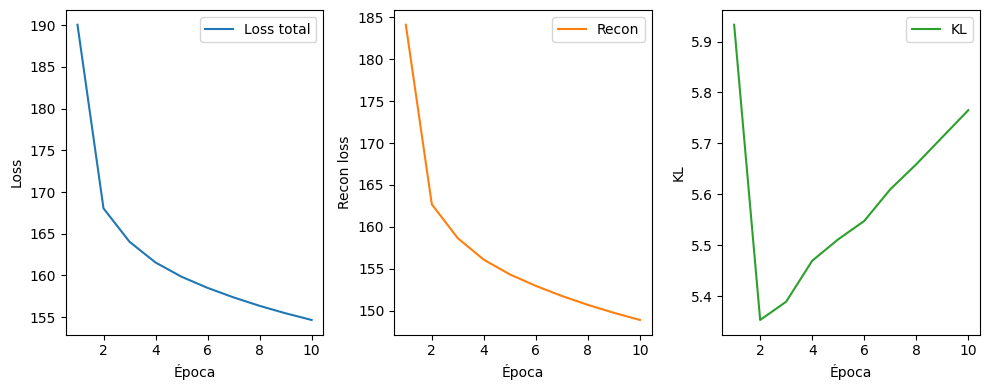

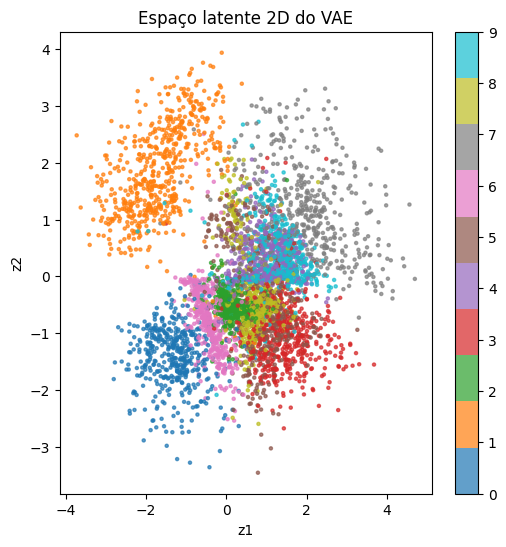

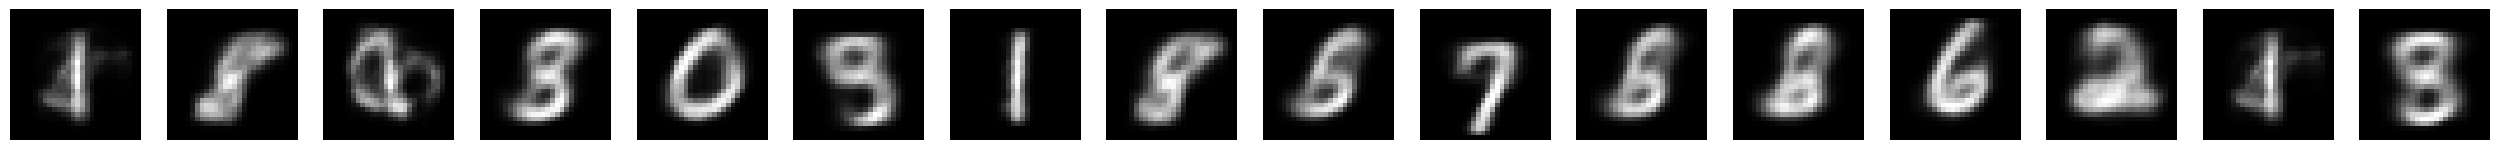

In [ ]:
train_loader, test_loader = get_mnist_loaders(batch_size=128)
model = VAE().to(device)
history = train_vae(model, train_loader, epochs=10, lr=1e-3)
plot_history(history)
zs, ys = encode_dataset(model, test_loader, max_batches=50)
plot_latent_space(zs, ys)
sample_vae(model, n=16)